<a href="https://colab.research.google.com/github/malikaadil-tech/AI_Battery_Intelligence_Platform/blob/main/01_Data_Exploration_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import google.colab
print("Running in Google Colab")


Running in Google Colab


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# Path to the project
project_path = "/content/drive/MyDrive/AI_Battery_Intelligence_Platform"

# List everything inside the project
os.listdir(project_path)

['notebooks', 'src', 'models', 'outputs', 'docs', 'data']

# AI Battery Intelligence Platform

## Notebook 1: NASA Battery Dataset Exploration

### Objective
Understand the structure of the NASA Battery Aging Dataset before preprocessing.

### Dataset
NASA Prognostics Center of Excellence (PCoE) Battery Aging Dataset

### Battery Used
B0005.mat

### Learning Outcomes
- Understand MATLAB (.mat) files
- Explore NASA dataset structure
- Understand charge/discharge/impedance cycles
- Locate SOH-related information

In [ ]:

# Standard Libraries

import os
import warnings

# Data Handling

import numpy as np
import pandas as pd


# MATLAB File Reader

import scipy.io


# Visualization

import matplotlib.pyplot as plt


# Ignore Warnings

warnings.filterwarnings("ignore")

In [ ]:

# Project Paths

PROJECT_PATH = "/content/drive/MyDrive/AI_Battery_Intelligence_Platform"

RAW_DATA_PATH = os.path.join(
    PROJECT_PATH,
    "data",
    "raw",
    "5. Battery Data Set",
    "1. BatteryAgingARC-FY08Q4"
)

print("Project Path :", PROJECT_PATH)
print("Raw Data Path :", RAW_DATA_PATH)

Project Path : /content/drive/MyDrive/AI_Battery_Intelligence_Platform
Raw Data Path : /content/drive/MyDrive/AI_Battery_Intelligence_Platform/data/raw/5. Battery Data Set/1. BatteryAgingARC-FY08Q4


In [ ]:
# verify dataset
files = sorted(os.listdir(RAW_DATA_PATH))

print(f"Total Files : {len(files)}\n")

for file in files:
    print(file)

Total Files : 5

B0005.mat
B0006.mat
B0007.mat
B0018.mat
README.gdoc


In [ ]:
# load matlab file
# load B0005.mat
#A .mat file is MATLAB's native data storage format.
battery_path = os.path.join(RAW_DATA_PATH, "B0005.mat")
battery_data = scipy.io.loadmat(battery_path)  # It returns a dictionary.

In [ ]:
# Inspect the Dictionary
# # Explore Keys
battery_data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'B0005'])

In [ ]:
# # Access Battery Object
battery  = battery_data['B0005']
print(type(battery))
battery.shape

<class 'numpy.ndarray'>


(1, 1)

In [ ]:
# The (1,1) array is just a container. The real information is inside it.
# NASA stored the battery as a MATLAB structure, and when SciPy imports MATLAB structs, it wraps them inside a 1×1 NumPy object array.

In [ ]:
# # Extract MATLAB Structure
battery = battery[0,0]
print(type(battery))

<class 'numpy.void'>


In [ ]:
print(battery.dtype.names)

('cycle',)


In [ ]:
# means the battery contains only one top-level field ie cycles
# Acess cycle data
cycles = battery['cycle']
print(type(cycles))
print(cycles.shape)

<class 'numpy.ndarray'>
(1, 616)


In [ ]:
# It means NASA performed approximately 616 experiments (cycles) on battery B0005.

#Each element represents one complete experiment (charge, discharge, or impedance).

In [ ]:
# explore first cycle 1 from 616 cycles
first_cycle = cycles[0,0]
print(type(first_cycle))
print(first_cycle.dtype.names)

<class 'numpy.void'>
('type', 'ambient_temperature', 'time', 'data')


In [ ]:
#  ambient_temp = Room temperature during the experiment.

In [ ]:
# explore data field
cycle_data = first_cycle["data"][0,0]
print(type(cycle_data))
print(cycle_data.dtype.names)

<class 'numpy.void'>
('Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_charge', 'Voltage_charge', 'Time')


In [ ]:
# So the very first experiment in B0005 is a charging experiment.
# identify first cycle type
print(first_cycle["type"][0])

charge


In [ ]:
# so first cycle is charging cycle
# now for SOH we require capacity but is not present in charge cycyle



In [ ]:
cycle = cycles[0, 0]

print(cycle["type"])
print(type(cycle["type"]))

print(cycle["type"][0])
print(type(cycle["type"][0]))

['charge']
<class 'numpy.ndarray'>
charge
<class 'numpy.str_'>


In [ ]:
# Count Different Types of Cycles
# now we apply a loop over 616 cycles to Read cycle - Read its type - Store it
cycle_types = [] # list of all types

for i in range(cycles.shape[1]):
  cycle = cycles[0,i]
  cycle_type = cycle["type"][0] # one type
  cycle_types.append(cycle_type)

print(set(cycle_types))   #  set(cycle_type) -removes duplicates and shows all unique experiment types.




{np.str_('charge'), np.str_('impedance'), np.str_('discharge')}


In [ ]:
# for computing SOH  we need to find all discharge cycles of this battery


In [ ]:
# find all discharge cycles
discharge_indices = [] # create a empty list
# loop through all 616 experiments
for i in range(cycles.shape[1]):
  cycle = cycles[0,i]  # pick one
  cycle_type = cycle["type"][0] # to find out type "What experiment is this?" charge, discharge , impedence
  if cycle_type == "discharge":
    discharge_indices.append(i) # store discharge cycle

print(f"Total Discharge cycles:{len(discharge_indices)}")
print(f"first 10 indices",discharge_indices[:10])


Total Discharge cycles:168
first 10 indices [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]


In [ ]:
# discharge cycles are at every odd pattern , ie repeteadly charge-discharge-charge-discharge
# like cycle 0- charge
# cycle 1- discharge


In [ ]:

# First Discharge Cycle

first_discharge = cycles[0, discharge_indices[0]]

print(first_discharge["type"][0])

discharge_data = first_discharge["data"][0,0]

print(discharge_data.dtype.names)

discharge
('Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load', 'Time', 'Capacity')


In [ ]:
# now we got the capacity which will use to find out SOH
# explore capacity of battery
capacity  = discharge_data["Capacity"]
print(type(capacity))
print(capacity.shape)
print(capacity)

<class 'numpy.ndarray'>
(1, 1)
[[1.85648742]]


In [ ]:
# first discharging dilevered 1.85648742 Ah
# so it is measured capacity during this specific discharge cycle not rated
# SOH= Measured Capacity/Rated Capacity

In [ ]:
# Extract Capacity from All Discharge Cycles
capacity_list = []  # to store capacity of each cycle
# looping over 168 discharge cycles
for j in discharge_indices:
  cycle = cycles[0,j]                             # one dischare cycle
  discharge_data = cycle["data"][0,0]             #Access the measurements.
  capacity = discharge_data["Capacity"][0,0]     # Extract the measured capacity.
  capacity_list.append(capacity)

print(f"Total Capacity values:{len(capacity_list)}")
print("\nFirst 10 capacity vlues are:\n",capacity_list[:10])



Total Capacity values:168

First 10 capacity vlues are:
 [np.float64(1.8564874208181574), np.float64(1.846327249719927), np.float64(1.8353491942234077), np.float64(1.8352625275821128), np.float64(1.8346455082120419), np.float64(1.8356616600675495), np.float64(1.8351461429226603), np.float64(1.8257567905665537), np.float64(1.8247738529891333), np.float64(1.824613268496936)]


In [ ]:
pd.Series(capacity_list, name="Capacity (Ah)")


,Capacity (Ah)
0,1.856487
1,1.846327
2,1.835349
3,1.835263
4,1.834646
...,...
163,1.293464
164,1.288003
165,1.287453
166,1.309015


Battery Capacity Degradation Curve  of B0005


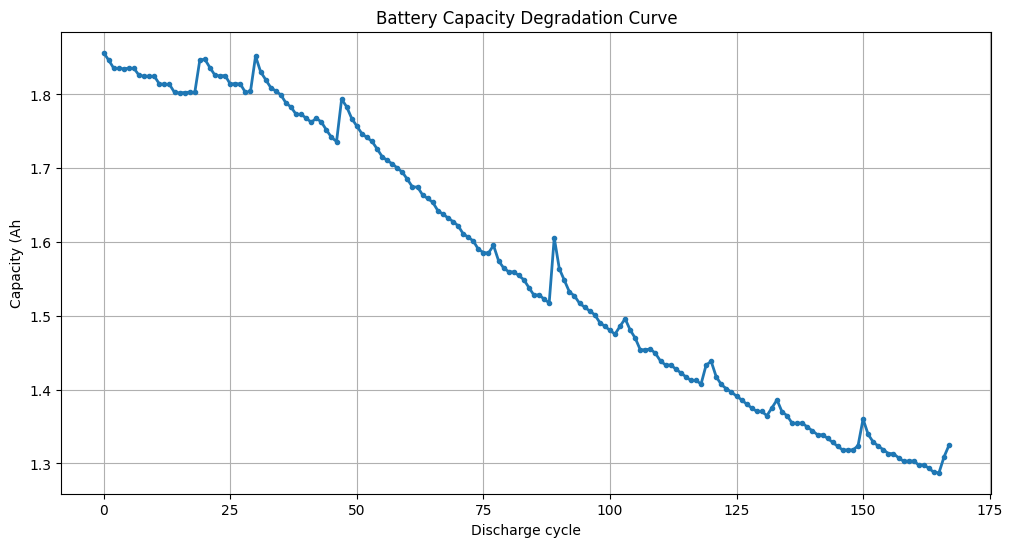

In [ ]:
# Battery Capacity Degradation Curve
print("Battery Capacity Degradation Curve  of B0005")
plt.figure(figsize =(12,6))
plt.plot(capacity_list,linewidth =2,label="Measured Capacity", marker='o',markersize=3,)
plt.title("Battery Capacity Degradation Curve")
plt.xlabel("Discharge cycle")
plt.ylabel("Capacity (Ah")
plt.grid(True)
plt.show()

In [ ]:
# here we can notice that degradation curve is non linear , we have several upward spikes in between
# these spikes are not errors
# this is due to several things
#Rest periods
#Electrochemical relaxation
#Temperature changes
#Measurement uncertainty

In [ ]:
# now we compute SOH
# SOH =  Measured capacity/ Rated capacity
# It tells us how healthy a battery is compared to when it was new

In [ ]:
# Compute State of Health (SOH)
Rated_capacity = 2.0 # 2AH
SOH_list = []
for capacity in capacity_list:
  SOH = capacity/Rated_capacity
  SOH_list.append(SOH)

print(f"Total SOH Values:{len(SOH_list)}")
pd.Series(SOH_list, name="SOH")


Total SOH Values:168


,SOH
0,0.928244
1,0.923164
2,0.917675
3,0.917631
4,0.917323
...,...
163,0.646732
164,0.644002
165,0.643726
166,0.654508


In [ ]:
battery_df = pd.DataFrame({
    "Cycle": range(1, len(capacity_list)+1),
    "Capacity (Ah)": capacity_list,
    "SOH": SOH_list
})

battery_df

,Cycle,Capacity (Ah),SOH
0,1,1.856487,0.928244
1,2,1.846327,0.923164
2,3,1.835349,0.917675
3,4,1.835263,0.917631
4,5,1.834646,0.917323
...,...,...,...
163,164,1.293464,0.646732
164,165,1.288003,0.644002
165,166,1.287453,0.643726
166,167,1.309015,0.654508


##Plot SOH Degradation Curve

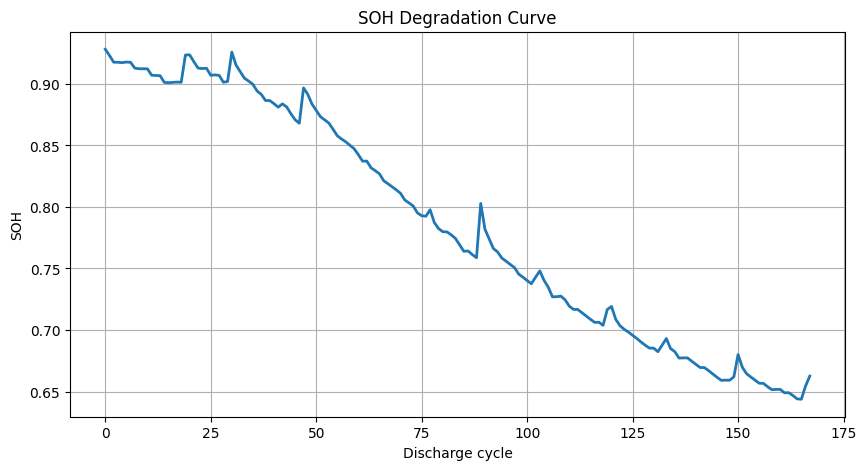

In [ ]:
# state of health degradation curve

plt.figure(figsize=(10,5))

plt.plot(SOH_list,linewidth =2)
plt.title("SOH Degradation Curve")
plt.xlabel("Discharge cycle")
plt.ylabel("SOH")
plt.grid(True)
plt.show()


In [ ]:
# using data we computed SOH Labels using the rated capacity
# these labels will supervised PHNN during training
# so after training PHNN directly predict SOH using Voltage, current, temp without requiring capacity


###Explore One Discharge Cycle Signals

In [ ]:
# Explore Raw Signals
print("Voltage shape:",discharge_data["Voltage_measured"].shape)
print("Current shape:",discharge_data["Current_measured"].shape)
print("Temperature shape:",discharge_data["Temperature_measured"].shape)
print("Time Shape :", discharge_data["Time"].shape)


Voltage shape: (1, 300)
Current shape: (1, 300)
Temperature shape: (1, 300)
Time Shape : (1, 300)


In [ ]:
#NASA measured the battery 300 times while it was discharging.
# so in cycle there are 300 voltages , current , temp and time
# ie Time Series

In [ ]:
## Extract Raw Signals
voltage = discharge_data["Voltage_measured"][0]
current = discharge_data["Current_measured"][0]
temperature = discharge_data["Temperature_measured"][0]
time = discharge_data["Time"][0]
print(len(voltage))
print(len(current))
print(len(temperature))
print(len(time))

300
300
300
300


In [ ]:
# so one discharge cycle is not one data point  - it is complete time series experiment with hundered of experiments

 Visualise Raw battery signals
 Because these are the actual signals that contain information about battery health.

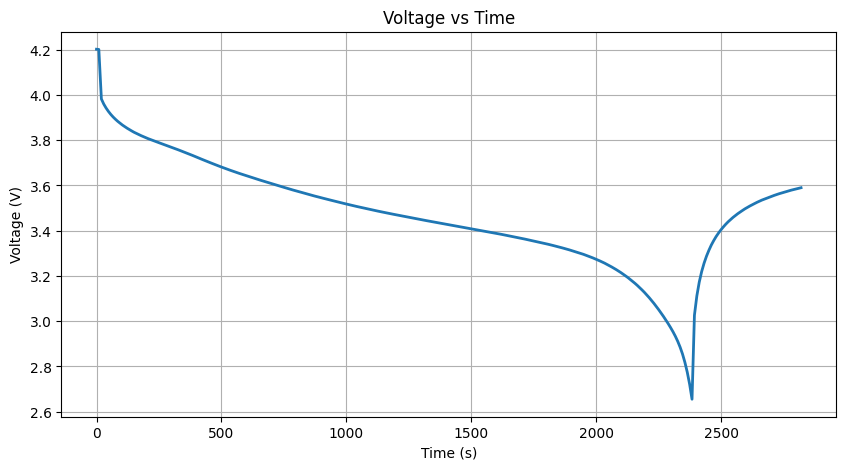

In [ ]:

# Voltage vs Time
plt.figure(figsize=(10,5))
plt.plot(time,voltage, linewidth =2)
plt.title("Voltage vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.grid(True)
plt.show()

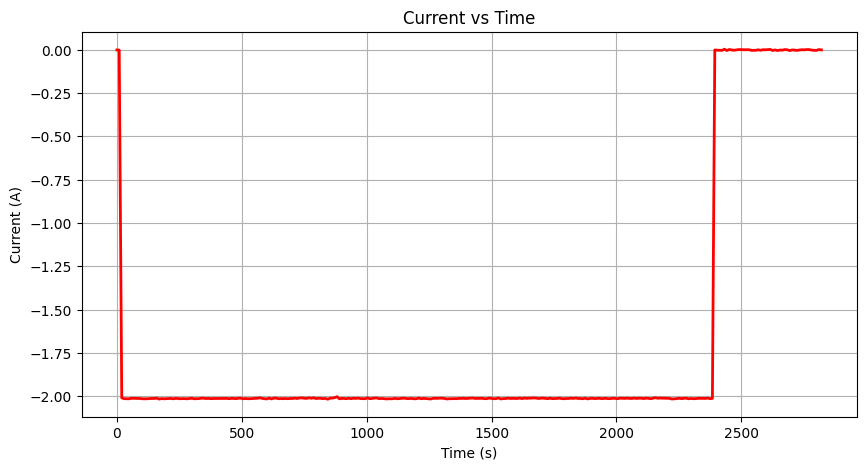

In [ ]:
# ==========================================
# Current vs Time
# ==========================================

plt.figure(figsize=(10,5))

plt.plot(time, current, color="red", linewidth=2)

plt.title("Current vs Time")

plt.xlabel("Time (s)")

plt.ylabel("Current (A)")

plt.grid(True)

plt.show()

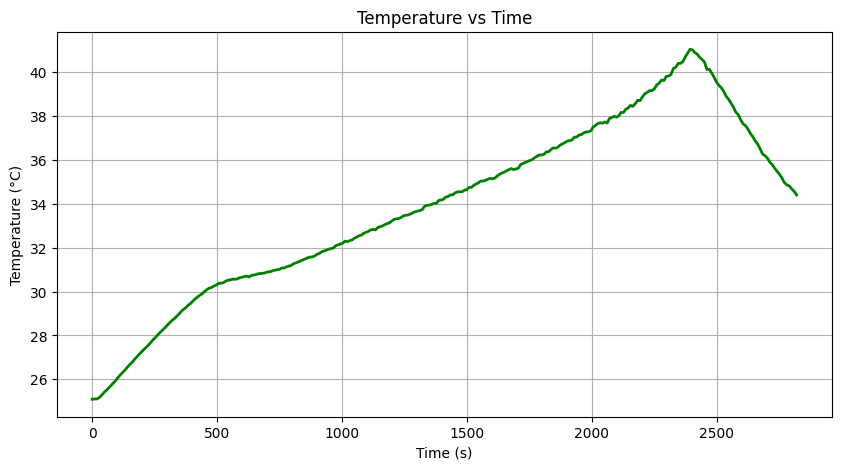

In [ ]:
# ==========================================
# Temperature vs Time
# ==========================================

plt.figure(figsize=(10,5))

plt.plot(time, temperature, color="green", linewidth=2)

plt.title("Temperature vs Time")

plt.xlabel("Time (s)")

plt.ylabel("Temperature (°C)")

plt.grid(True)

plt.show()

## Create Battery Summary Dataset

In [ ]:
# Create Battery Summary Dataset
battery_summary = pd.DataFrame({
    "cycle":range(1,len(capacity_list)+1),
    "capacity":capacity_list,
    "SOH":SOH_list
})
battery_summary.head()

,cycle,capacity,SOH
0,1,1.856487,0.928244
1,2,1.846327,0.923164
2,3,1.835349,0.917675
3,4,1.835263,0.917631
4,5,1.834646,0.917323


### Save Summary Dataset

In [ ]:
# Save Summary Dataset
processed_path = os.path.join(PROJECT_PATH,"data","processed")
os.makedirs(processed_path,exist_ok =True)

summary_path = os.path.join(processed_path,"B0005_summary.csv")

battery_summary.to_csv(summary_path,index=False)
print("saved succesfully")
print(summary_path)


saved succesfully
/content/drive/MyDrive/AI_Battery_Intelligence_Platform/data/processed/B0005_summary.csv


### Create Master Dataset

In [ ]:
# create master dataset
battery_raw_dataset = []                                   #    create empty list
Rated_capacity=2.0
for cycle_number,idx in enumerate(discharge_indices,start =1):     # for cycle number 1 2 3 4.... and  idx(nasa_cycle_index) -- 1 3 5 7 9 ..... as discharge cycle are odd
  cycle = cycles[0,idx]
  data = cycle["data"][0,0]
  # store a dictionary in a list
  battery_raw_dataset.append({
      "cycle_number": cycle_number,
      "nasa_cycle_index": idx,
      "voltage":data["Voltage_measured"][0], # store diff 300 voltage readings
      "current":data["Current_measured"][0], # store diff 300 current readings
      "temperature":data["Temperature_measured"][0], # store diff 300 temperature readings
      "time":data["Time"][0],                     # store diff 300 timestamps readings
      "capacity":float(data["Capacity"][0,0]),
      "soh":float(data["Capacity"][0]/Rated_capacity )

  })
print(f"total samples:{len(battery_raw_dataset)}")



total samples:168


### Save Master Dataset

In [ ]:
# Save Master Dataset

import pickle
# pickle is python library used to save and load python objects
# through this we can save permanently and will store on disk
# pickle store data efficiently

raw_dataset_path = os.path.join(processed_path,"B0005_raw.pkl")
#  os.path.join , it automatically handles path separators (/ or \) across different operating systems.
# Create the full path where the dataset will be saved

with open(raw_dataset_path,"wb") as f:      # wb - write binary , in write it create a new file if already then overwrite it, pickle save binary
  pickle.dump(battery_raw_dataset,f)

print("master dataset saved succesfully")
print(raw_dataset_path)




master dataset saved succesfully
/content/drive/MyDrive/AI_Battery_Intelligence_Platform/data/processed/B0005_raw.pkl


#### Verify Saved Dataset


In [ ]:
# verify saved dataset
with open(raw_dataset_path,"rb") as f:    # rb is read binary
  loaded_dataset = pickle.load(f)

print("Total smples", len(loaded_dataset))
print("\nKeys of first sample:\n")
print(loaded_dataset[0].keys())

Total smples 168

Keys of first sample:

dict_keys(['cycle_number', 'nasa_cycle_index', 'voltage', 'current', 'temperature', 'time', 'capacity', 'soh'])


In [ ]:
print(capacity)
print(type(capacity))

1.3250793286429356
<class 'numpy.float64'>
